In [2]:
from cycler import cycler
import matplotlib.pyplot as plt
import numpy as np
import pickle

# from cora.ensembles.helpers import *
from cora.momenta import *

In [6]:
ensemble = "H106"
Nbst = 100

# LOAD RATIOS
def load_ratios(ensemble, source_set, kind):
    path = f"/glurch/scratch/kic04594/data/misc/{ensemble}/{ensemble}-{kind}-ISOVECTOR-AXIAL-RATIOS-NBST{Nbst}-{source_set}.pkl"
    with open(path, "rb") as f:
        return pickle.load(f)

ratios_spat_s2 = load_ratios(ensemble, "source_set2", "SPATIAL")
ratios_spat_s4 = load_ratios(ensemble, "source_set4", "SPATIAL")

In [7]:
qmax = 8
qcol: dict[str] = momentum_index_dict(qmax)
qidx = qcol['(0, 0, 0)']

qidx_to_qvec = {qidx: qstr for qstr, qidx in qcol.items()}
qvec = qidx_to_qvec[qidx]

#print(momentum_index_dict.items())

SOURCE-SINK SEPARATION
10
LHP
CENTRAL VALUES
[1.62191046 1.61229433 1.61599319 1.65802579 1.6700418  1.64413878
 1.60947265 1.55873335 1.55015396 1.53406607 1.5062961 ]
STANDARD ERRORS
[0.08383094 0.0837522  0.07757915 0.08569049 0.08276328 0.06933633
 0.0711168  0.08579194 0.09766286 0.11889054 0.14859406]
REG
CENTRAL VALUES
[1.55592255 1.56785869 1.57706842 1.59387309 1.6116561  1.57823929
 1.53885346 1.51625667 1.47457819 1.46456545 1.47618892]
STANDARD ERRORS
[0.04704769 0.0458192  0.04387114 0.04451791 0.04771291 0.04378496
 0.05172281 0.05307536 0.05721669 0.05049259 0.04642701]
LHP
CENTRAL VALUES
[1.61193999 1.68114149 1.72948057 1.74194068 1.70038212 1.68015865
 1.71866647 1.67385354 1.66672382 1.72562502 1.72321504]
STANDARD ERRORS
[0.11473196 0.12208024 0.14688008 0.17659253 0.15172381 0.13218817
 0.14002091 0.1145743  0.11163107 0.14444143 0.13970283]
REG
CENTRAL VALUES
[1.5238072  1.63822798 1.71961803 1.74678277 1.74282699 1.75622481
 1.76277396 1.74818106 1.75764733 1.730

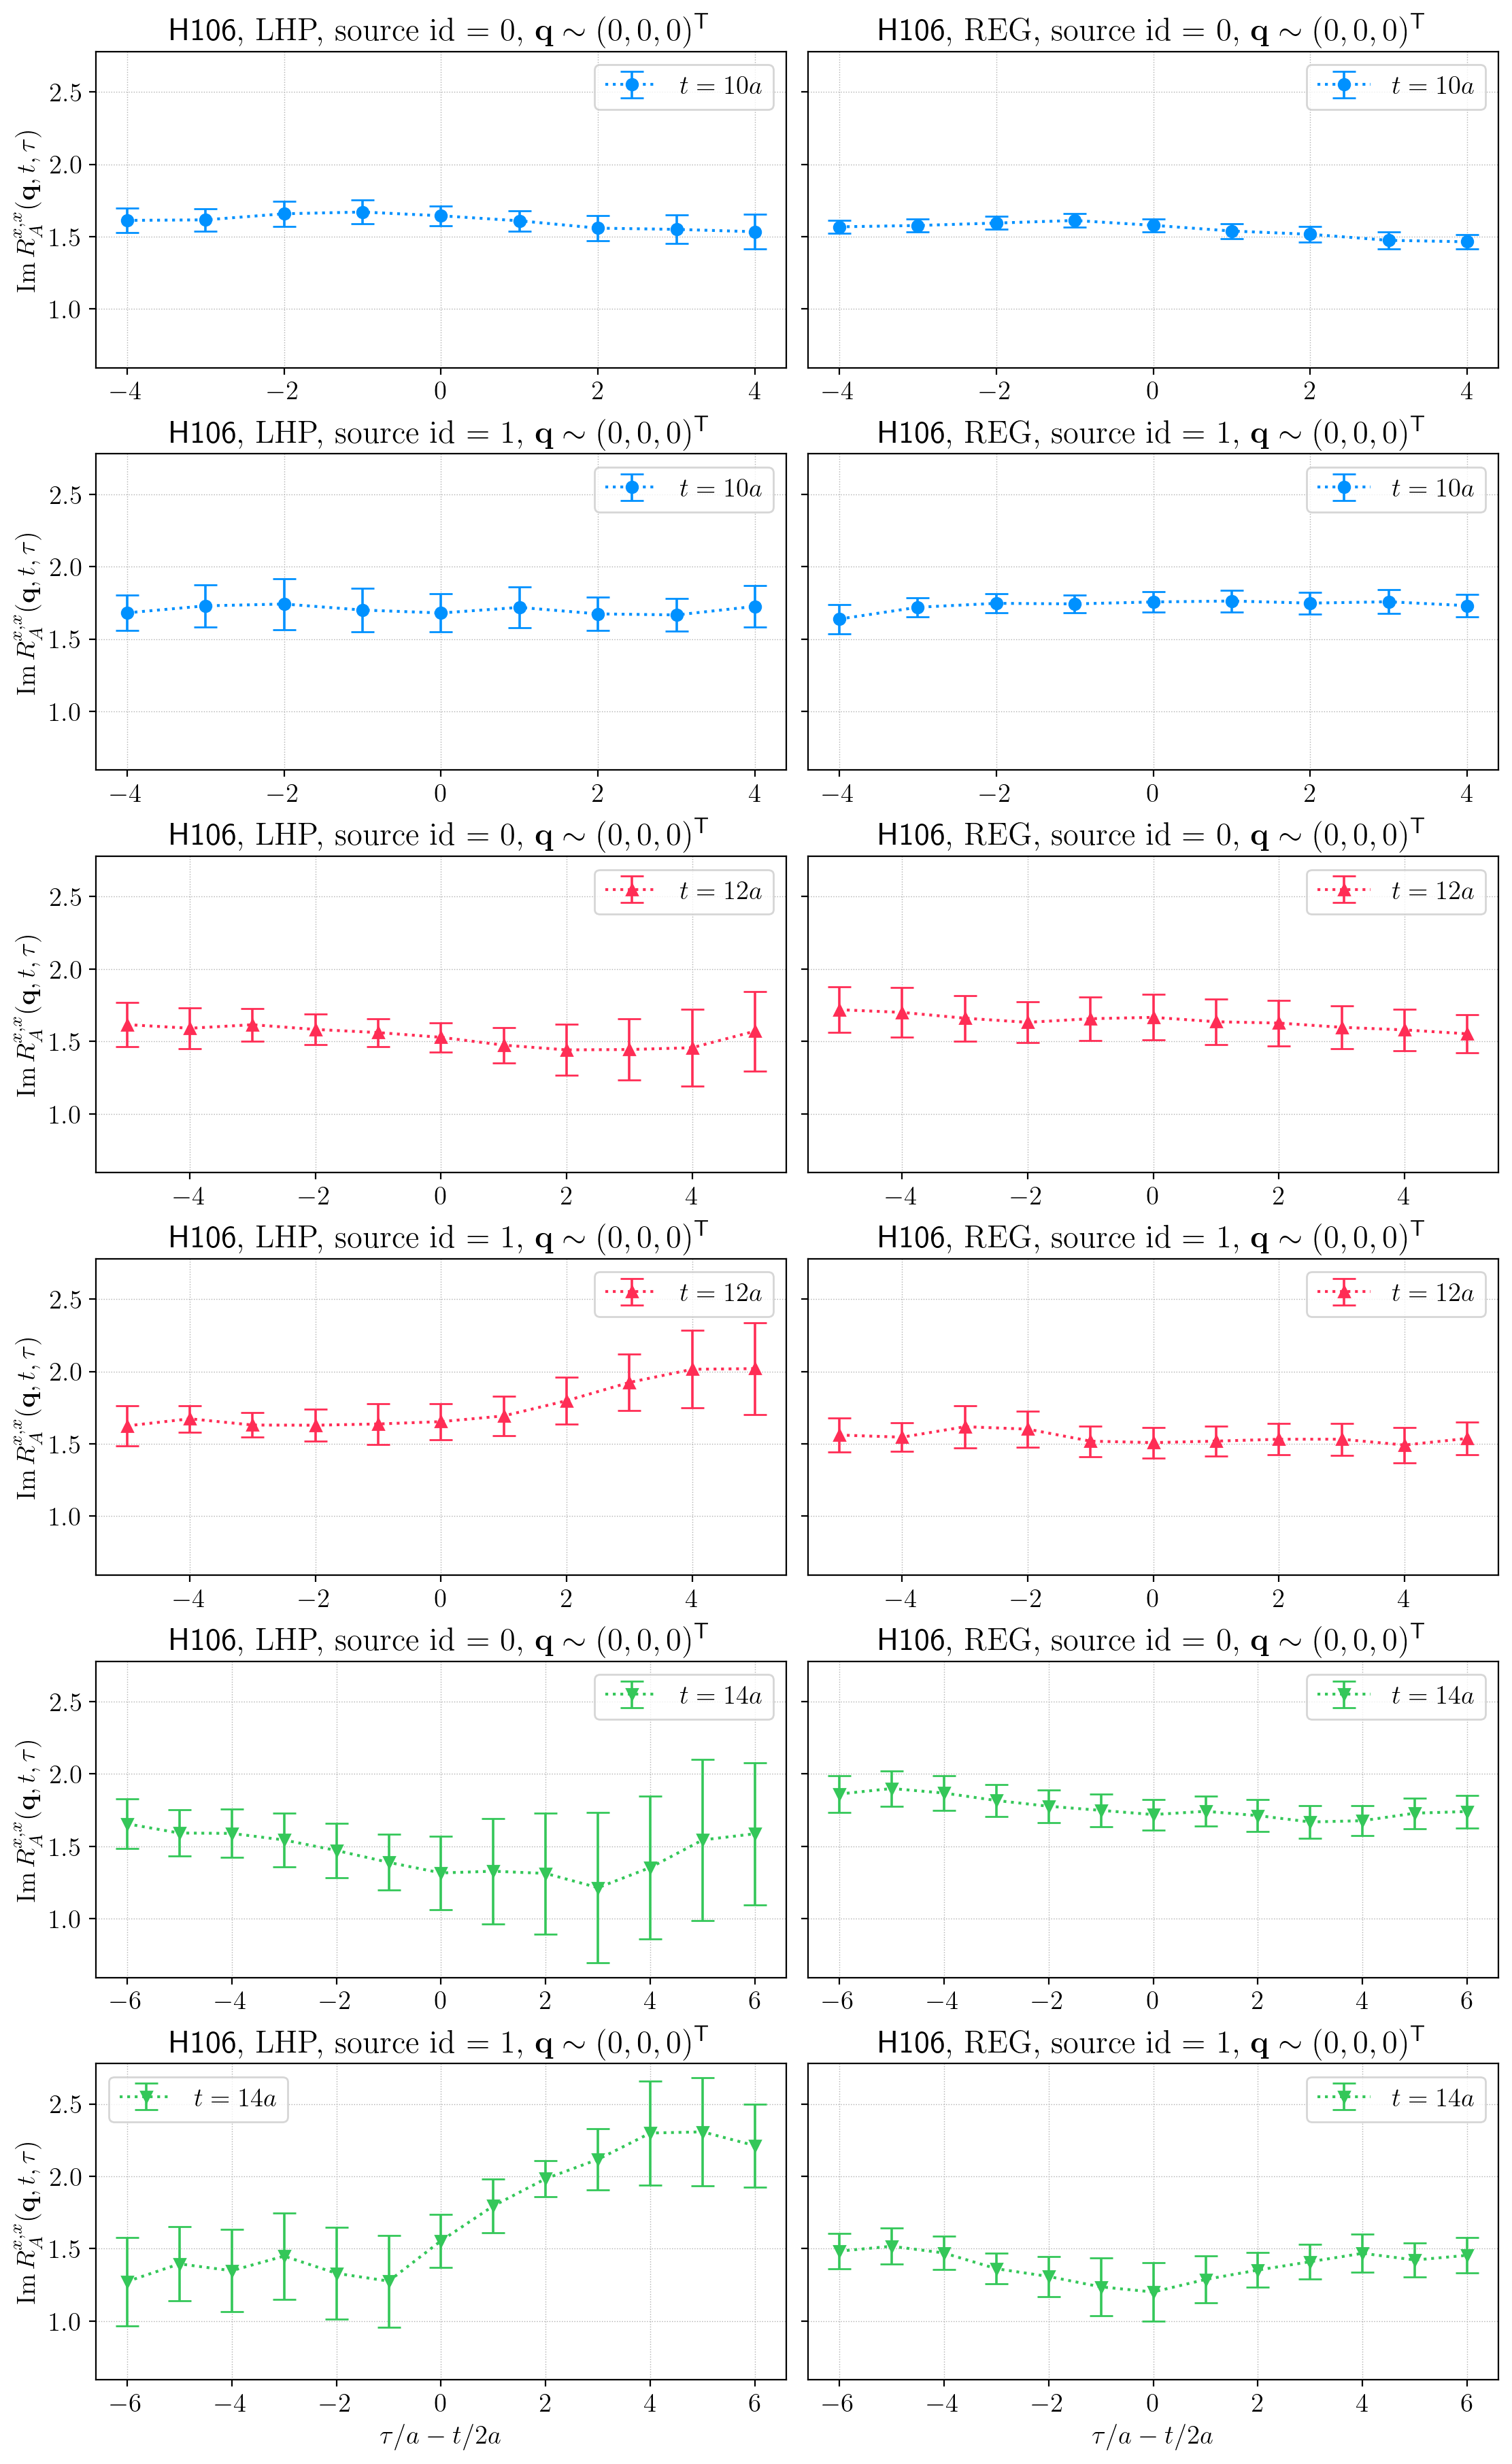

In [9]:
plt.rcParams.update({
    "font.size": 14,
    "font.family": "computer modern",
    "text.usetex": True,
    "figure.dpi": 200,
    "axes.prop_cycle": cycler(color=[
        "#0091ff",  # blue
        "#ff8d28",  # orange
        "#34C759",  # green
        "#ff2d55",  # pink
    ])
})

# select polarisation x and current direction x 
ipol_X = 0   # X
jcur_x = 0   # x

ts = [10, 12, 14]
src_ids_to_plot = [0, 1]  # two rows

def mean_err_over_bootstrap(arr):
    mu = arr.mean(axis=0)
    err = arr.std(axis=0, ddof=1)
    return mu, err

def get_tau_curve(ratios_dict, t, source_set, src_id, ipol, jcur):
    A = ratios_dict[t][source_set]  # (Nbst, Npol, Ncur, Nsrc, Nmom, Ntau)
    return A[:, ipol, jcur, src_id, qidx, :]  # (Nbst, Ntau)

def tau_axis(Ntau, centered: bool):
    if centered:
        return np.arange(Ntau) - (Ntau - 1) / 2
    return np.arange(Ntau)

t_color = {10: "#0091ff", 12: "#ff2d55", 14: "#34C759"}
t_marker = {10: "o", 12: "^", 14: "v"}
markersize = 6
capsize = 6
elinewidth = 1.3

fig, axes = plt.subplots(
    nrows=len(src_ids_to_plot) * len(ts),  # 6 rows
    ncols=2,
    figsize=(11, 18),
    sharex=False,
    sharey=True,
    constrained_layout=True,
)

for it, t in enumerate(ts):
    colour = t_color[t]

    print("SOURCE-SINK SEPARATION")
    print(t)

    for row, src_id in enumerate(src_ids_to_plot):
        global_row = it * len(src_ids_to_plot) + row

        for col, (label, ratios, source_set) in enumerate([
            ("LHP", ratios_spat_s2, "source_set2"),
            ("REG", ratios_spat_s4, "source_set4"),
        ]):
            ax = axes[global_row, col]

            y_bst = get_tau_curve(ratios, t, source_set, src_id, ipol=ipol_X, jcur=jcur_x)
            est, err = mean_err_over_bootstrap(y_bst)

            tau = tau_axis(len(est), centered=(qidx == 0))

            print(label)
            print("CENTRAL VALUES")
            print(est)
            print("STANDARD ERRORS")
            print(err)

            ax.errorbar(
                tau[1:-1],
                est[1:-1],
                yerr=err[1:-1],
                marker=t_marker[t],
                markersize=markersize,
                linestyle=":",
                color=colour,
                elinewidth=elinewidth,
                capsize=capsize,
                label=rf"$t={t}a$",
            )

            ax.grid(True, linestyle=":", linewidth=0.5)

            ax.set_title(
                rf"$\mathsf{{{ensemble}}},$ {label}, source id = {src_id}, "
                rf"$\mathbf{{q}} \sim {qvec}^{{\mathsf{{T}}}}$"
            )

            if global_row == len(ts) * len(src_ids_to_plot) - 1:
                ax.set_xlabel(r"$\tau/a - t/2a$" if qidx == 0 else r"$\tau/a$")

            if col == 0:
                ax.set_ylabel(r"$\mathrm{Im}\,R_A^{x,x}(\mathbf{q}, t, \tau)$")
            ax.legend()

plt.show()